# Nama: M. Fadhly Andrian
# NIM: 4222311015
# Kelas:A MALAM


In [93]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [80]:
DATASET_PATH = "TrashType_Image_Dataset"

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

print(os.path.exists(DATASET_PATH))

True


In [81]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.15
)

In [82]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print(train_generator.class_indices)

print("Jumlah data training:",
      train_generator.samples)

print("Jumlah data validation:",
      validation_generator.samples)

Found 2150 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Jumlah data training: 2150
Jumlah data validation: 377


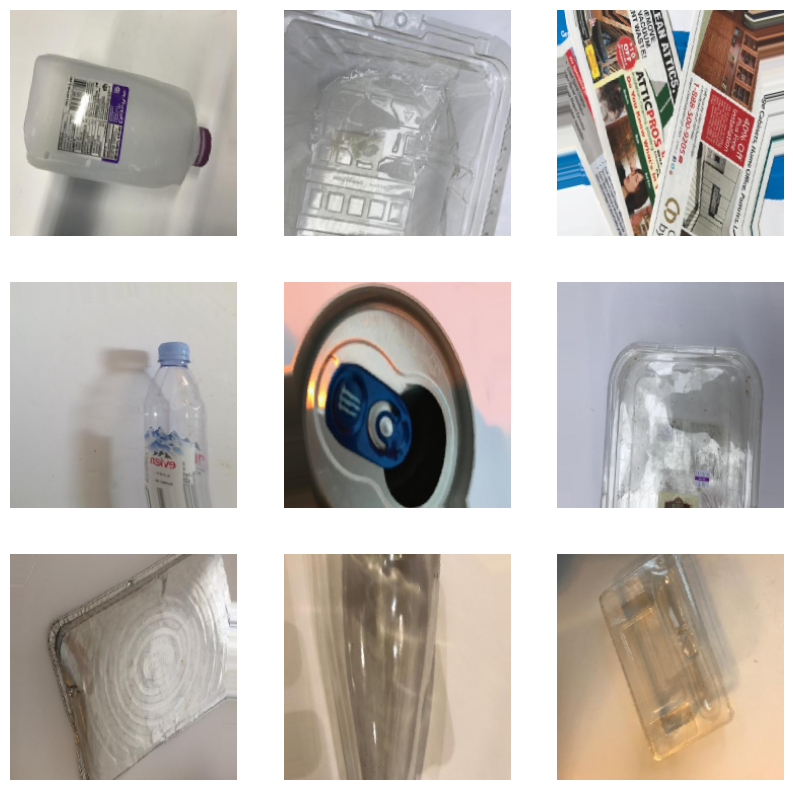

In [83]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [84]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(
    train_generator.num_classes,
    activation='softmax'
))

c:\Users\MOH SYURIL ISWAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [87]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.2744 - loss: 1.8370 - val_accuracy: 0.3263 - val_loss: 1.5614
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 38s 563ms/step - accuracy: 0.3716 - loss: 1.5087 - val_accuracy: 0.4138 - val_loss: 1.4603
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 38s 560ms/step - accuracy: 0.4349 - loss: 1.4072 - val_accuracy: 0.4589 - val_loss: 1.2915
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 607ms/step - accuracy: 0.4544 - loss: 1.3779 - val_accuracy: 0.4907 - val_loss: 1.2966
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 607ms/step - accuracy: 0.4721 - loss: 1.3167 - val_accuracy: 0.5040 - val_loss: 1.2730


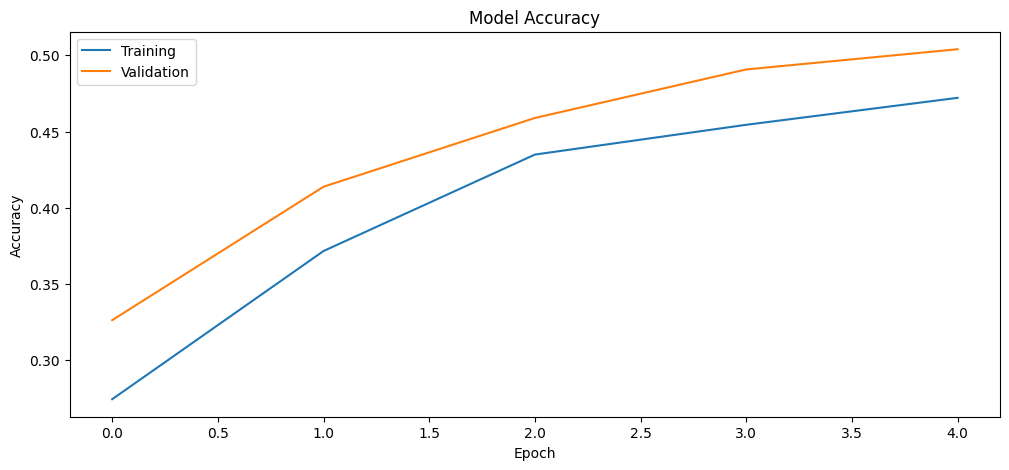

In [88]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

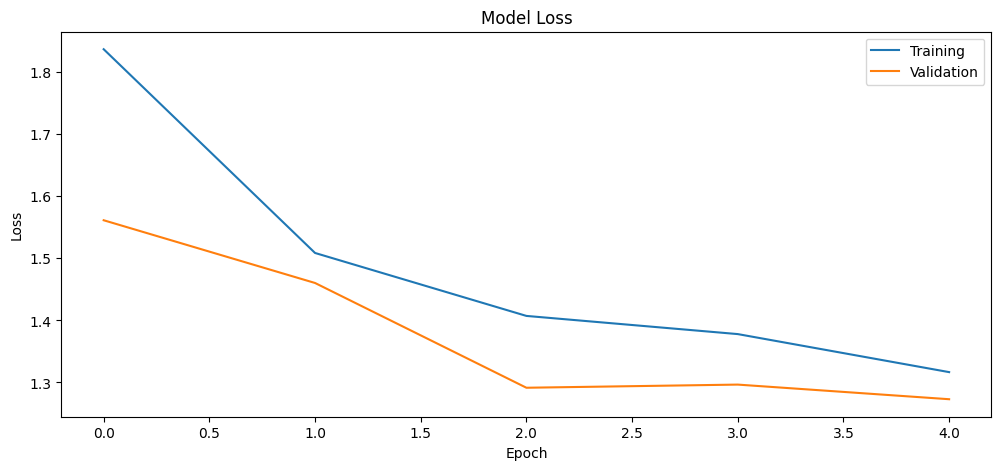

In [89]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

In [90]:
loss, accuracy = model.evaluate(
    validation_generator
)

print("Accuracy :", accuracy)
print("Loss :", loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - accuracy: 0.4987 - loss: 1.2656
Accuracy : 0.4986737370491028
Loss : 1.2656415700912476


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 321ms/step


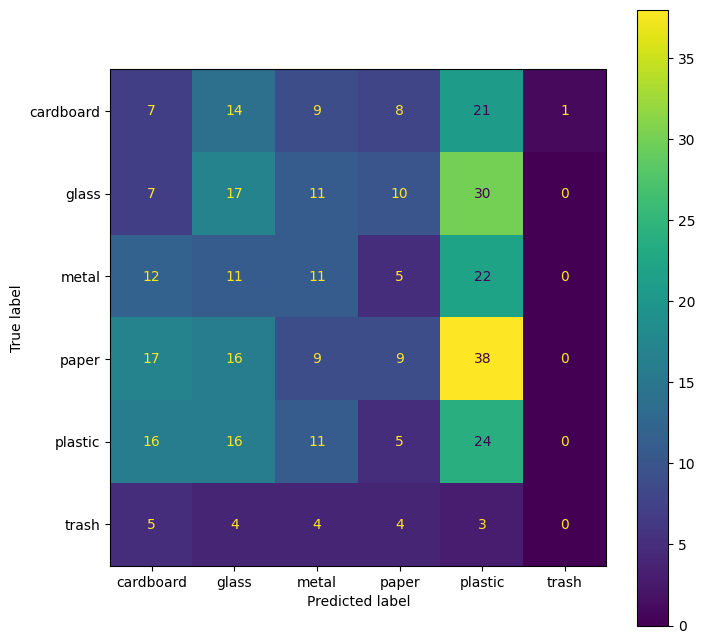

In [91]:
validation_generator.reset()

predictions = model.predict(
    validation_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = validation_generator.classes

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(
        validation_generator.class_indices.keys()
    )
)

fig, ax = plt.subplots(
    figsize=(8,8)
)

disp.plot(ax=ax)

plt.show()

In [92]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(
            validation_generator.class_indices.keys()
        )
    )
)

              precision    recall  f1-score   support

   cardboard       0.11      0.12      0.11        60
       glass       0.22      0.23      0.22        75
       metal       0.20      0.18      0.19        61
       paper       0.22      0.10      0.14        89
     plastic       0.17      0.33      0.23        72
       trash       0.00      0.00      0.00        20

    accuracy                           0.18       377
   macro avg       0.15      0.16      0.15       377
weighted avg       0.18      0.18      0.17       377



## Kesimpulan

Pada praktikum ini telah diterapkan metode Convolutional Neural Network (CNN) untuk melakukan klasifikasi gambar pada Trash Type Image Dataset. Tahapan yang dilakukan meliputi persiapan dataset, preprocessing citra, augmentasi data, perancangan model CNN, proses pelatihan, serta evaluasi hasil model.

Hasil pengujian menunjukkan nilai akurasi yang sangat tinggi, yaitu mencapai 100% dengan nilai loss yang sangat kecil. Namun setelah dilakukan analisis lebih lanjut, diketahui bahwa dataset yang digunakan hanya terdiri dari satu kategori sampah, yaitu cardboard. Kondisi tersebut menyebabkan model hanya mengenali satu kelas sehingga hasil akurasi yang diperoleh belum dapat dijadikan acuan untuk menilai kemampuan klasifikasi secara keseluruhan.

Dari praktikum ini dapat disimpulkan bahwa keberagaman data sangat berpengaruh terhadap performa dan validitas model CNN. Untuk memperoleh hasil yang lebih representatif, diperlukan penggunaan seluruh kategori data yang tersedia sehingga model dapat mempelajari karakteristik masing-masing jenis sampah dan menghasilkan proses klasifikasi yang lebih akurat.
